In [ ]:
"""
For first time setup:

!git clone https://github.com/google/deluca 
!git checkout improved-api

%cd deluca

!pip install -e .
"""

%cd ..

!pip install -e .

/Users/rsalik/Documents/Code/Google/deluca


/Users/rsalik/.pyenv/versions/3.13.1/lib/python3.13/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Obtaining file:///Users/rsalik/Documents/Code/Google/deluca
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for deluca (pyproject.toml) ... done
  Created wheel for deluca: filename=deluca-0.0.17-0.editable-py3-none-any.whl size=8167 sha256=c5475eecb5506bc057dbb4aa431be2215ff411d3779188271c9856347e85d33d
  Stored in directory: /private/var/folders/zd/pxlq94zd389bp96dgw56b0900000gn/T/pip-ephem-wheel-cache-ycn9glmb/wheels/6e/ce/1b/6c4512f4b38168466dee61d1ca5f9765d0c15735eb0d3491c2
Successfully built deluca
^C
Traceback (most recent call last):
  File "/Users/rsalik/.pyenv/versions/3.13.1/envs/deluca-env/bin/pip", line 8, in <module>
    sys.exit(main())
             ~~~~^^
  File "/Users/rsalik/.pyenv/versions/3.13.1/envs/deluca-env/lib/python3.13/site-packages/pip/_internal/cli/main.py", line 79, in main
    r

In [ ]:
!pip install -q ipympl
# Must restart kernel after this

/Users/rsalik/.pyenv/versions/3.13.1/lib/python3.13/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


In [1]:
%matplotlib widget

In [2]:
%load_ext autoreload
%autoreload 1

import jax

from deluca.agents.new.linear import LinearAgent
from deluca.filters.spectral import SpectralFilter
from deluca.learners.memory import Memory
from deluca.agents.new.linear import DefaultSettings as LinearAgentDefaultSettings
from deluca.utils.printing import Task

# JAX random key
rng = jax.random.key(0)

### **Creating an Environment**

In [3]:
%autoreload 1

import jax

from deluca.envs._brax import BraxEnv

# Creating the environment
rng, env_rng = jax.random.split(rng)
env = BraxEnv(env_rng, "inverted_double_pendulum")

/Users/rsalik/.pyenv/versions/3.13.1/envs/deluca-env/lib/python3.13/site-packages/brax/io/mjcf.py:480: UserWarning: Brax System, piplines and environments are not actively being maintained. Please see MJX for a well maintained JAX-based physics engine: https://github.com/google-deepmind/mujoco/tree/main/mjx. For a host of environments that use MJX, see: https://github.com/google-deepmind/mujoco_playground.
  warnings.warn(


#### **Defining a loss function**

In [4]:
from jax import Array
from typing import Any
import jax.numpy as jnp


from jax import Array
from typing import Any
import jax.numpy as jnp


def loss_fn(action: Array, next_state: Any, next_obs: Array) -> Array:
    """Inverted Double Pendulum Loss

    Observation Space
    - 0: Position of Cart on Linear Surface
    - 1: Vertical Angle of Pole on the Cart (goal: keep straight up)
    - 2: Linear Velocity of the Cart (goal: minimize)
    - 3: Angular Velocity of the pole on the cart (goal: minimize)"""

    penalties = jnp.array([0, 10, 0.1, 0.7])
    return jnp.sum(jnp.square(next_obs) * penalties) + next_state.done * 50

### **Setting up an Agent**
1. Create a memory -- lets the agent store the history of observations and actions, and can add Spectral Filtering
2. Define the agent's settings, or use default
3. Create the agent itself

In [5]:
%autoreload 1

# 1. Create a memory
filter = SpectralFilter(env.observation_size, env.action_size)
memory = Memory(1, env.observation_size, env.action_size, filter=filter)

# 2. Define the agent's settings, or use default
settings = LinearAgentDefaultSettings.replace(learning_rate=1e-3, loss_fn=loss_fn) # type: ignore

# 3. Create the agent itself
rng, agent_rng = jax.random.split(rng)
agent = LinearAgent(memory, settings, rng=agent_rng)

#### **Create a Training Loop**

In [6]:
%autoreload 1

rng, env_rng = jax.random.split(rng)
t, state, obs = env.reset(env_rng)

losses = []
states = [state]

N = 1000

with Task("Training agent", N) as task:
    for rng in jax.random.split(rng, N):
        arng, erng = jax.random.split(rng)
        
        loss, (new_t, new_state, new_obs), action = agent.step_and_update(env, t, state, memory.get_history(), arng)
        
        if (new_t == 0):
            memory.reset() # Episode reset

        states.append(new_state)

        memory.store(obs, action)

        losses.append(loss)

        t, state, obs = new_t, new_state, new_obs

        task.update(text=f"Loss: {loss:.4f}")


✔ Training agent [██████████████████████████████] [Completed 1000]


#### **Plotting Results**

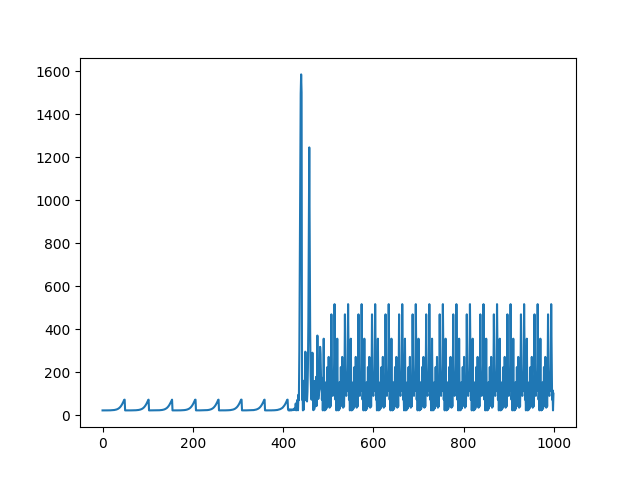

In [25]:
import matplotlib.pyplot as plt

plt.cla()
plt.plot(losses)
plt.show()

#### **Rendering the trajectory**


**Note:** Only Brax environments support rendering. The process for displaying the render is different in Jupyter notebooks than Python scripts.

In [26]:
%autoreload 1

from IPython.display import display
from IPython.display import HTML


display(HTML(env.render(states)))
